In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Load the scaled dataset from the previous step
df_scaled = pd.read_csv("../Data/Preprocessed/Preprocessed.csv")
print("Data shape:", df_scaled.shape)
df_scaled.head()

Data shape: (5000, 21)


,age,gender,plan_type,tenure_months,monthly_revenue_usd,total_call_minutes,data_usage_gb,sms_count,intl_call_minutes,roaming_enabled,...,support_tickets_6mo,days_since_last_call,num_services_subscribed,auto_pay_enrolled,paperless_billing,contract_type,region_East,region_North,region_South,region_West
0,0.282710,-0.972771,-0.096664,0.433507,-0.277783,-0.289662,-0.972645,-0.414478,-0.545286,-0.841913,...,-0.656999,0.771235,0.708594,0.721262,0.652161,-0.156360,1.980217,-0.497499,-0.509047,-0.487467
1,0.771681,-0.972771,-1.579246,-0.762349,-0.410246,-0.912136,-1.016143,-0.632266,-0.590714,-0.841913,...,0.704657,0.943961,-1.415489,-1.386459,0.652161,1.010505,-0.504995,2.010055,-0.509047,-0.487467
2,1.260651,-0.972771,0.644627,-1.130305,-0.676191,-1.095028,-1.091987,-1.067840,-0.772428,-0.841913,...,-0.656999,0.771235,-0.707462,-1.386459,0.652161,-1.323225,-0.504995,-0.497499,1.964456,-0.487467
3,0.527196,-0.972771,-1.579246,-0.701023,-0.636401,-1.322840,-1.044027,-0.842543,-0.726999,-0.841913,...,-0.656999,0.713660,0.000566,-1.386459,-1.533364,-0.156360,-0.504995,-0.497499,-0.509047,2.051422
4,-1.673171,-0.972771,1.385917,-0.455719,0.923901,2.037663,2.064445,1.260232,0.045283,-0.841913,...,0.704657,1.231839,1.416622,-1.386459,-1.533364,-0.156360,-0.504995,2.010055,-0.509047,-0.487467


In [2]:
inertia = []
silhouette_scores = []
K_range = range(2, 11)   # test K from 2 to 10

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = kmeans.fit_predict(df_scaled)
    inertia.append(kmeans.inertia_)
    score = silhouette_score(df_scaled, labels)
    silhouette_scores.append(score)
    print(f"K={k:2d} | Inertia: {kmeans.inertia_:10.2f} | Silhouette: {score:.4f}")

K= 2 | Inertia:   80695.65 | Silhouette: 0.2361
K= 3 | Inertia:   75597.59 | Silhouette: 0.1026
K= 4 | Inertia:   72457.72 | Silhouette: 0.1063
K= 5 | Inertia:   68951.84 | Silhouette: 0.1103
K= 6 | Inertia:   66156.36 | Silhouette: 0.1130
K= 7 | Inertia:   63567.75 | Silhouette: 0.1175
K= 8 | Inertia:   61242.91 | Silhouette: 0.1209
K= 9 | Inertia:   59929.77 | Silhouette: 0.1122
K=10 | Inertia:   58787.07 | Silhouette: 0.1157


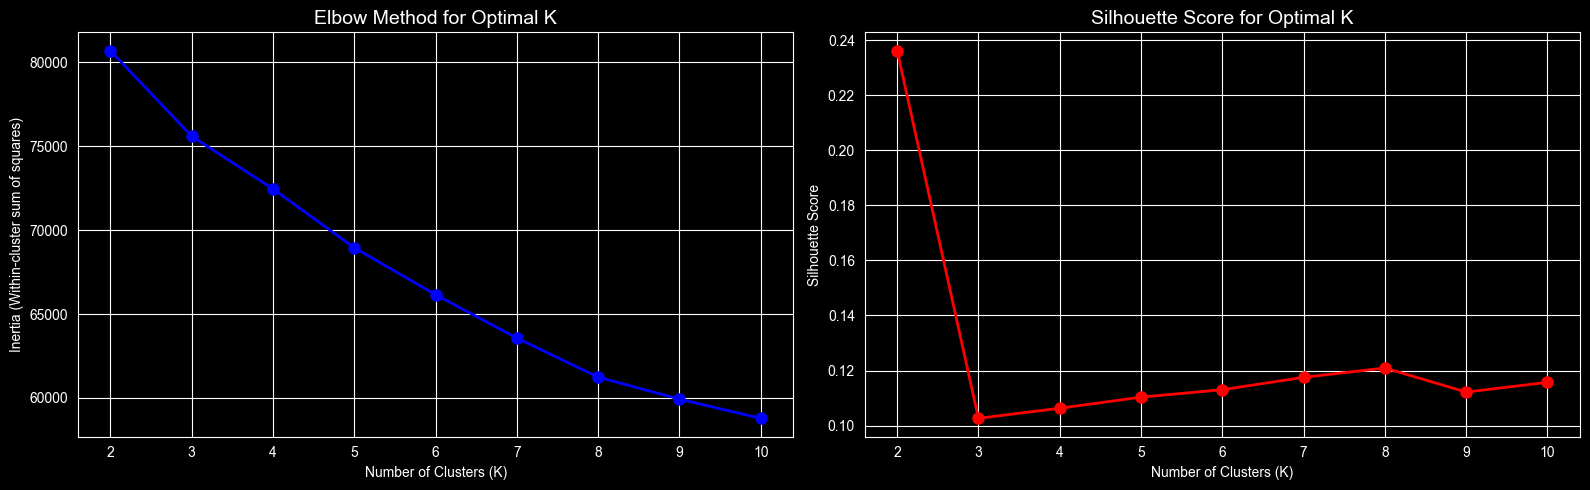

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Elbow plot (inertia)
axes[0].plot(K_range, inertia, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method for Optimal K', fontsize=14)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (Within-cluster sum of squares)')
axes[0].grid(True)

# Silhouette plot
axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score for Optimal K', fontsize=14)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [4]:
best_k = K_range[silhouette_scores.index(max(silhouette_scores))]
print(f"\n✅ Best number of clusters by Silhouette Score: {best_k}")
print(f"   Corresponding Silhouette Score: {max(silhouette_scores):.4f}")


✅ Best number of clusters by Silhouette Score: 2
   Corresponding Silhouette Score: 0.2361
